# CohortFACTM evaluation on COVID-19 (Su et al.)

Runs the cohort test suite on real COVID-19 multi-omics data (metabolome +
proteome). Each test compares **CohortFACTM** (`ZPrior.COHORT`) with a
**baseline FACTM** (`ZPrior.STD_NORMAL`). No ground truth; the WHO scale (0–7)
is a soft reference. Fits are cached on disk.

## 0 — Setup: imports, configuration, helpers
Shared helpers: model fitting, cohort-effect extraction (`E[γ]`, `E[δ]`),
distances, loadings / ARD relevance, reconstruction R², and clustering metrics.

In [2]:
import os, sys, time, warnings
sys.path.insert(0, os.path.abspath('..'))   # repo root
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import linear_sum_assignment
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score,
                             adjusted_mutual_info_score, fowlkes_mallows_score,
                             homogeneity_completeness_v_measure)
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering

from src import FACTModel
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig
from covid_data.load_covid import load_covid
from scipy.stats import spearmanr

# Disable tqdm progress bars: each update is an IOPub message, which on Windows
# (proactor + extra selector thread for zmq) is ~8x slower than the
# fit itself. Without it a single K=10 fit can hang for minutes.
import src.build_model as _bm
_bm.tqdm = lambda x, *a, **k: x

sns.set_context('notebook')
pd.set_option('display.width', 120)

# ----- global experiment settings -----
HEADLINE_K = 5      # K for the main experiments
PI         = 0.5    # spike-and-slab P(gamma=1) — headline (see 6b)
MAX_ITER   = 60     # CAVI iterations (reduced from 100 — large K x pi grid)
SEED       = 0
print(f'HEADLINE_K={HEADLINE_K}  PI={PI}  MAX_ITER={MAX_ITER}  SEED={SEED}')

HEADLINE_K=5  PI=0.5  MAX_ITER=60  SEED=0


In [3]:
# ----------------------- dopasowanie modeli -----------------------
def fit_cohort(views, K, pi=PI, max_iter=MAX_ITER, seed=SEED):
    '''CohortFACTM: WPrior.ARD_SS + ZPrior.COHORT, spike-and-slab prior `pi`.'''
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL,
                                              w_prior=WPrior.ARD_SS)
                             for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.COHORT] * K,
        cohort_prior_config=CohortPriorConfig(pi=pi),
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def fit_baseline(views, K, max_iter=MAX_ITER, seed=SEED):
    '''Standardowy FACTM z izotropowym priorem N(0,1) — bez struktury kohortowej.'''
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL,
                                              w_prior=WPrior.ARD_SS)
                             for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.STD_NORMAL] * K,
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def cohort_gamma_delta(model, K):
    '''Macierze (C, K): E[gamma] i E[delta]. Wiersze wg np.unique(cohorts).'''
    priors = model.fa.node_z.z_priors
    assert priors[0].__class__.__name__ == 'CohortZPrior', 'model nie ma cohort-prior'
    E_g = np.column_stack([priors[k].E_gamma for k in range(K)])
    E_d = np.column_stack([priors[k].E_delta for k in range(K)])
    return E_g, E_d


def extract_cohort_effects(model, cohort_labels, K):
    '''E[gamma], E[delta], nazwy kohort i ELBO z dopasowanego modelu kohortowego.'''
    E_g, E_d = cohort_gamma_delta(model, K)
    return {'E_gamma': E_g, 'E_delta': E_d,
            'cohorts': np.array(sorted(np.unique(cohort_labels))),
            'elbo': float(model.elbo_sequence[-1])}

In [4]:
# --------------- distances / Hungarian / W stability ---------------
def cohort_dist(M):
    '''Pairwise L2 distances between rows of M (cohort positions in latent space).'''
    diffs = M[:, None, :] - M[None, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))


def cohort_positions(model, K):
    '''(C, K) pozycje kohort w przestrzeni utajonej z E[gamma * delta].'''
    pr = model.fa.node_z.z_priors
    return np.column_stack([pr[k].E_gamma * pr[k].E_delta for k in range(K)])


def hungarian(Z_a, Z_b):
    '''Match columns of Z_b to Z_a maximising sum |corr|; returns perm and signs.'''
    K = Z_a.shape[1]
    corr = np.array([[np.corrcoef(Z_a[:, i], Z_b[:, j])[0, 1]
                      for j in range(K)] for i in range(K)])
    row, col = linear_sum_assignment(-np.abs(corr))
    signs = np.sign(corr[row, col]); signs[signs == 0] = 1
    return col, signs.astype(float)


def w_stability(model_a, model_b, K):
    '''Per-view per-factor |corr(W_a, W_b)| after matching factors via Z.'''
    perm, signs = hungarian(model_a.get_latent_factors(),
                            model_b.get_latent_factors())
    out = []
    for v in range(len(model_a.fa.nodelist_w)):
        Wa = model_a.fa.nodelist_w[v].E_w
        Wb = model_b.fa.nodelist_w[v].E_w
        out.append(np.array([abs(np.corrcoef(Wa[:, k], Wb[:, perm[k]] * signs[k])[0, 1])
                             for k in range(K)]))
    return out, perm, signs


def severity_from_label(label):
    '''Cohort label -> WHO value (or bin midpoint).'''
    s = str(label).strip().lower()
    if s in ('mild', 'moderate', 'severe'):
        return {'mild': 0.5, 'moderate': 3.0, 'severe': 6.0}[s]
    if s.startswith('sev') and s[3:].isdigit():
        return float(s[3:])
    if '-' in s:
        a, b = s.split('-'); return (float(a) + float(b)) / 2
    if s == 'non_hosp':
        return 1.0
    if s == 'hosp':
        return 5.0
    return float('nan')

In [5]:
# --------------- metryki klastrowania ---------------
def clustering_metrics(X, labels):
    '''silhouette / Calinski-Harabasz: higher=better; Davies-Bouldin / within-between: lower=better.'''
    out = {}
    out['silhouette'] = float(silhouette_score(X, labels))
    out['davies_bouldin'] = float(davies_bouldin_score(X, labels))
    out['calinski_harabasz'] = float(calinski_harabasz_score(X, labels))
    uniq = np.unique(labels)
    cents = np.array([X[labels == c].mean(0) for c in uniq])
    within = np.mean([np.linalg.norm(X[labels == c] - cents[i], axis=1).mean()
                      for i, c in enumerate(uniq)])
    bp = cents[:, None, :] - cents[None, :, :]
    between = np.sqrt((bp ** 2).sum(-1))[np.triu_indices(len(cents), 1)].mean()
    out['within/between'] = float(within / between)
    return out


def cluster_cohorts(D, k_range=(2, 3, 4)):
    '''Agglomerative + k-means + spectral on the (C, C) distance matrix; silhouette per method.'''
    C = D.shape[0]
    rows, labels = [], {}
    coords = MDS(n_components=min(C - 1, 5), dissimilarity='precomputed',
                 random_state=0, n_init=4).fit_transform(D)
    for k in k_range:
        if k >= C:
            continue
        agg = AgglomerativeClustering(n_clusters=k, metric='precomputed',
                                      linkage='average').fit(D)
        sil_agg = silhouette_score(D, agg.labels_, metric='precomputed') \
            if len(set(agg.labels_)) > 1 else np.nan
        rows.append({'method': 'agglomerative', 'k': k, 'silhouette': sil_agg})
        labels[('agglomerative', k)] = agg.labels_
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(coords)
        sil_km = silhouette_score(D, km.labels_, metric='precomputed') \
            if len(set(km.labels_)) > 1 else np.nan
        rows.append({'method': 'kmeans', 'k': k, 'silhouette': sil_km})
        labels[('kmeans', k)] = km.labels_
        gamma = 1.0 / (2 * (D[D > 0].mean() ** 2 + 1e-9))
        A = np.exp(-gamma * D ** 2)
        sp = SpectralClustering(n_clusters=k, affinity='precomputed',
                                random_state=0, assign_labels='kmeans').fit(A)
        sil_sp = silhouette_score(D, sp.labels_, metric='precomputed') \
            if len(set(sp.labels_)) > 1 else np.nan
        rows.append({'method': 'spectral', 'k': k, 'silhouette': sil_sp})
        labels[('spectral', k)] = sp.labels_
    return pd.DataFrame(rows), labels


def cluster_samples(Z, true_labels, k_range=(2, 3, 4)):
    '''Cluster N samples in Z; silhouette + ARI/NMI vs true cohort labels.'''
    rows, labels = [], {}
    true = np.asarray(true_labels)
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
        agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(Z)
        for name, lab in [('kmeans', km.labels_), ('agglomerative', agg.labels_)]:
            sil = silhouette_score(Z, lab) if len(set(lab)) > 1 else np.nan
            h, comp, v = homogeneity_completeness_v_measure(true, lab)
            rows.append({'method': name, 'k': k, 'silhouette': sil,
                         'ARI': adjusted_rand_score(true, lab),
                         'NMI': normalized_mutual_info_score(true, lab),
                         'AMI': adjusted_mutual_info_score(true, lab),
                         'V_measure': v,
                         'FMI': fowlkes_mallows_score(true, lab)})
            labels[(name, k)] = lab
    if len(set(true)) > 1:
        rows.append({'method': 'TRUE_LABELS', 'k': len(set(true)),
                     'silhouette': silhouette_score(Z, true),
                     'ARI': 1.0, 'NMI': 1.0, 'AMI': 1.0,
                     'V_measure': 1.0, 'FMI': 1.0})
    return pd.DataFrame(rows), labels

In [6]:
# --------------- W loadings, factor relevance, reconstruction ---------------
def get_W(model, view_idx=0):
    '''Loading matrix E[W] (D x K) for a simple view.'''
    return np.asarray(model.fa.nodelist_w[view_idx].E_w)


def factor_alpha(model, view_idx=0):
    '''ARD precision E[alpha] per factor (small = relevant, large = pruned by ARD).
    Falls back to 1/energy when the ARD node has no E_alpha.'''
    wn = model.fa.nodelist_w[view_idx]
    for attr in ('alpha_m_node', 'node_alpha', 'alpha_node'):
        node = getattr(wn, attr, None)
        if node is not None and hasattr(node, 'E_alpha'):
            return np.asarray(node.E_alpha)
    e = np.linalg.norm(np.asarray(wn.E_w), axis=0)
    return 1.0 / np.maximum(e, 1e-9)


def reconstruct(model, views, view_idx=0):
    '''Zwraca (Y, Y_hat = Z·Wᵀ) — obserwacje i rekonstrukcja widoku z modelu.'''
    Z = np.asarray(model.get_latent_factors())
    W = get_W(model, view_idx)
    Y = np.asarray(views.simple[view_idx].data)
    return Y, Z @ W.T


def r2_view(Y, Yh):
    '''R² of the whole view (1 = perfect reconstruction).'''
    return 1.0 - ((Y - Yh) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()


def n_relevant_factors(model, view_idx=0, rel_thr=0.05):
    '''Number of factors with relative loading energy ‖W[:,k]‖ > rel_thr * max.'''
    e = np.linalg.norm(get_W(model, view_idx), axis=0)
    return int((e / e.max() > rel_thr).sum()) if e.max() > 0 else 0


def mean_r2(model, views):
    '''Mean reconstruction R² over all simple views.'''
    return float(np.mean([r2_view(*reconstruct(model, views, vi))
                          for vi in range(views.num_simple)]))


def abscorr(a, b):
    '''|corr| robust to constant columns (returns nan instead of erroring).'''
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return abs(np.corrcoef(a, b)[0, 1])

def abscorr_spear(a, b):
    '''|Spearman rho| — korelacja rang, do zmiennych ordinalnych (np. WHO).'''
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return abs(spearmanr(a, b)[0])

In [7]:
# --------------- two-level cache (RAM -> disk -> fit) for data and fits ---------------
import joblib
DATA = {}
FITS = {}
CACHE_DIR = '.fit_cache'          # persistent fit cache across runs (gitignored)
os.makedirs(CACHE_DIR, exist_ok=True)


def get_data(mode):
    if mode not in DATA:
        DATA[mode] = load_covid(cohort_mode=mode, standardize=True)
    return DATA[mode]


def get_fit(mode, kind, K=HEADLINE_K, pi=PI, max_iter=MAX_ITER, seed=SEED):
    '''Dopasuj lub wczytaj model `kind` ('cohort'/'baseline'). Cache: RAM -> dysk -> fit.

    Each fit is saved to disk once computed, so runs are RESUMABLE: if the
    notebook dies midway, the next run loads finished fits in seconds and computes
    only the missing ones. The baseline does not depend on pi, so its key omits pi.'''
    pi_key = round(float(pi), 3) if kind == 'cohort' else None
    key = (mode, kind, K, pi_key, max_iter, seed)
    if key in FITS:
        return FITS[key]
    path = os.path.join(CACHE_DIR, '_'.join(str(x) for x in key).replace('.', 'p') + '.joblib')
    if os.path.exists(path):
        m = joblib.load(path)
        FITS[key] = m
        return m
    views = get_data(mode).views
    t0 = time.time()
    if kind == 'cohort':
        m = fit_cohort(views, K=K, pi=pi, max_iter=max_iter, seed=seed)
    elif kind == 'baseline':
        m = fit_baseline(views, K=K, max_iter=max_iter, seed=seed)
    else:
        raise ValueError(kind)
    print(f'  [fit] {mode:12s} {kind:8s} K={K:<2d} pi={str(pi_key):<5} -> '
          f'ELBO={float(m.elbo_sequence[-1]):.0f}  ({time.time()-t0:.0f}s)')
    joblib.dump(m, path, compress=3)
    FITS[key] = m
    return m


def plot_cohort_effects(out, K, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(11, 0.55 * len(out['cohorts']) + 2))
    sns.heatmap(out['E_gamma'] * out['E_delta'], annot=True, fmt='.2f', cmap='coolwarm',
                center=0, xticklabels=[f'Z{k}' for k in range(K)],
                yticklabels=out['cohorts'], ax=axes[0])
    axes[0].set_title(f'{title_prefix} — E[γ·δ] (cohort profile)')
    sns.heatmap(out['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=[f'Z{k}' for k in range(K)],
                yticklabels=out['cohorts'], ax=axes[1])
    axes[1].set_title(f'{title_prefix} — E[γ] (activation)')
    plt.tight_layout(); plt.show()

## 1 — Data and cohort partitions
Two simple views (metabolome + proteome), z-scored per feature. Cohort labels
come from the WHO scale in three partitions (`per_severity`, `grouped`,
`binary`).

In [8]:
for mode in ['per_severity', 'grouped', 'binary']:
    d = get_data(mode)
    print(f'=== {mode} ===  N={d.views.N}  D_metab={d.views.simple[0].D}  D_prot={d.views.simple[1].D}')
    print(pd.Series(d.cohorts).value_counts().sort_index().to_string(), '\n')

=== per_severity ===  N=378  D_metab=1050  D_prot=464
sev0    124
sev1    104
sev2      2
sev3     44
sev4     55
sev5     22
sev6     12
sev7     15 

=== grouped ===  N=378  D_metab=1050  D_prot=464
mild        228
moderate    101
severe       49 

=== binary ===  N=378  D_metab=1050  D_prot=464
hosp        148
non_hosp    230 



## 2 — Experiment 1: `per_severity` with a `K` sweep
One cohort per WHO value. Inspect `E[γ]` and `E[γ·δ]`, then refit for
`K = 3…10, 15, 20` tracking ELBO, active cohort factors, R², and relevant
factors.

ELBO  cohort=-676522   baseline=-678492


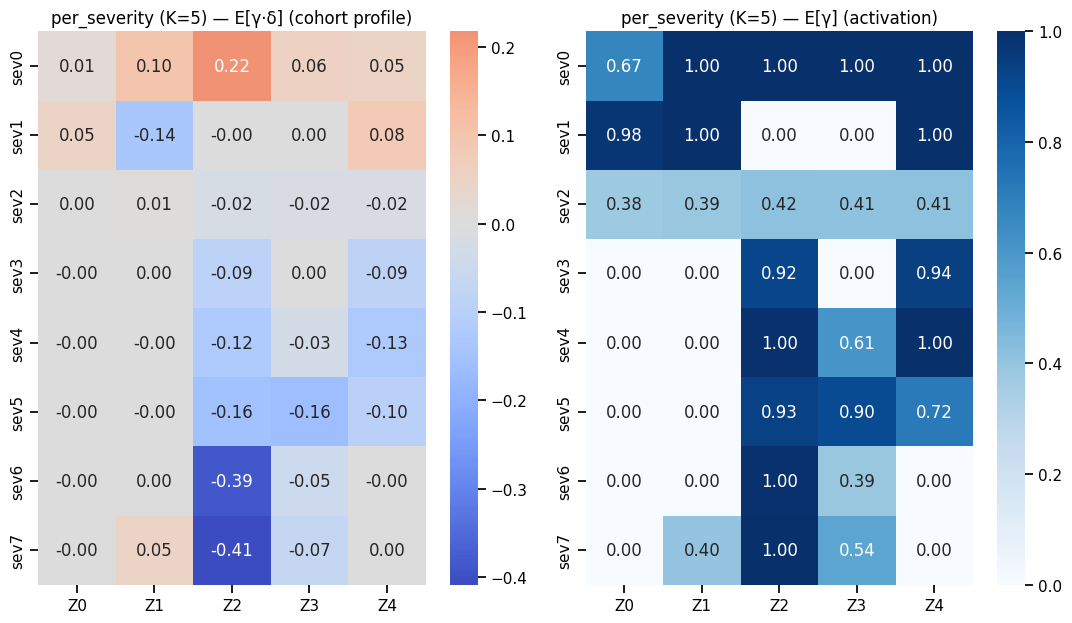

In [9]:
# --- Part A: headline K=5 ---
mode = 'per_severity'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'per_severity (K=5)')

### 2a — Cohort profile: cohort vs baseline
`E[γ·δ]` (CohortFACTM) next to the per-cohort mean of `Z_hat` (baseline), on the
same colour scale.

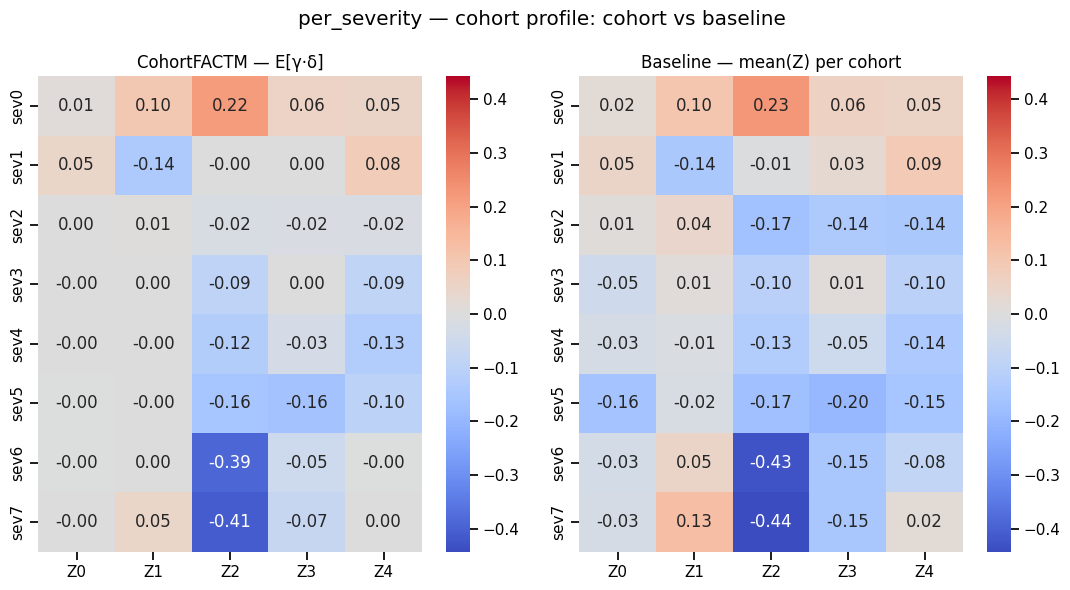

In [10]:
# Part A (baseline) — baseline cohort profile = mean(Z) per cohort
# The baseline has no E[γ·δ]; its profile counterpart is the mean Z_hat within a cohort
# (averaged over patients in the group). Same colour scale = direct comparison.
mode = 'per_severity'
d = get_data(mode)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
mc = get_fit(mode, 'cohort', K=HEADLINE_K)
names, codes = np.unique(d.cohorts, return_inverse=True)
prof_base = np.array([mb.get_latent_factors()[codes == i].mean(0) for i in range(len(names))])
out = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
prof_cohort = out['E_gamma'] * out['E_delta']
fl = [f'Z{k}' for k in range(HEADLINE_K)]
vmax = max(np.abs(prof_cohort).max(), np.abs(prof_base).max())

fig, axes = plt.subplots(1, 2, figsize=(11, 0.5 * len(names) + 2))
sns.heatmap(prof_cohort, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=fl, yticklabels=names, ax=axes[0])
axes[0].set_title('CohortFACTM — E[γ·δ]')
sns.heatmap(prof_base, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=fl, yticklabels=names, ax=axes[1])
axes[1].set_title('Baseline — mean(Z) per cohort')
plt.suptitle('per_severity — cohort profile: cohort vs baseline')
plt.tight_layout(); plt.show()

In [11]:
# --- Part B: sweep K = 3..10, 15, 20 ---
K_RANGE = [3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
ACTIVE_THR = 0.5
views = get_data(mode).views
rows = []
for K in K_RANGE:
    mc = get_fit(mode, 'cohort',   K=K)
    mbk = get_fit(mode, 'baseline', K=K)
    E_g, _ = cohort_gamma_delta(mc, K)
    g_mean = E_g.mean(axis=0)
    rows.append({'K': K,
                 'elbo_cohort':   float(mc.elbo_sequence[-1]),
                 'elbo_baseline': float(mbk.elbo_sequence[-1]),
                 'n_active': int((g_mean > ACTIVE_THR).sum()),
                 'n_relevant_W': n_relevant_factors(mc, 0),
                 'R2_cohort': mean_r2(mc, views),
                 'R2_baseline': mean_r2(mbk, views)})
df_K = pd.DataFrame(rows)
df_K['elbo_gap'] = df_K['elbo_cohort'] - df_K['elbo_baseline']
print(df_K.round(3).to_string(index=False))

Pretraining FA
Fitting model
  [fit] per_severity baseline K=3  pi=None  -> ELBO=-708752  (17s)
Pretraining FA
Fitting model
  [fit] per_severity cohort   K=4  pi=0.5   -> ELBO=-690594  (18s)
Pretraining FA
Fitting model
  [fit] per_severity baseline K=4  pi=None  -> ELBO=-692222  (17s)
Pretraining FA
Fitting model
  [fit] per_severity cohort   K=6  pi=0.5   -> ELBO=-668929  (26s)
Pretraining FA
Fitting model
  [fit] per_severity baseline K=6  pi=None  -> ELBO=-671256  (30s)
Pretraining FA
Fitting model
  [fit] per_severity cohort   K=7  pi=0.5   -> ELBO=-659424  (33s)
Pretraining FA
Fitting model
  [fit] per_severity baseline K=7  pi=None  -> ELBO=-662103  (34s)
Pretraining FA
Fitting model
  [fit] per_severity cohort   K=8  pi=0.5   -> ELBO=-640835  (41s)
Pretraining FA
Fitting model
  [fit] per_severity baseline K=8  pi=None  -> ELBO=-644037  (39s)
Pretraining FA
Fitting model
  [fit] per_severity cohort   K=9  pi=0.5   -> ELBO=-636460  (45s)
Pretraining FA
Fitting model
  [fit] per

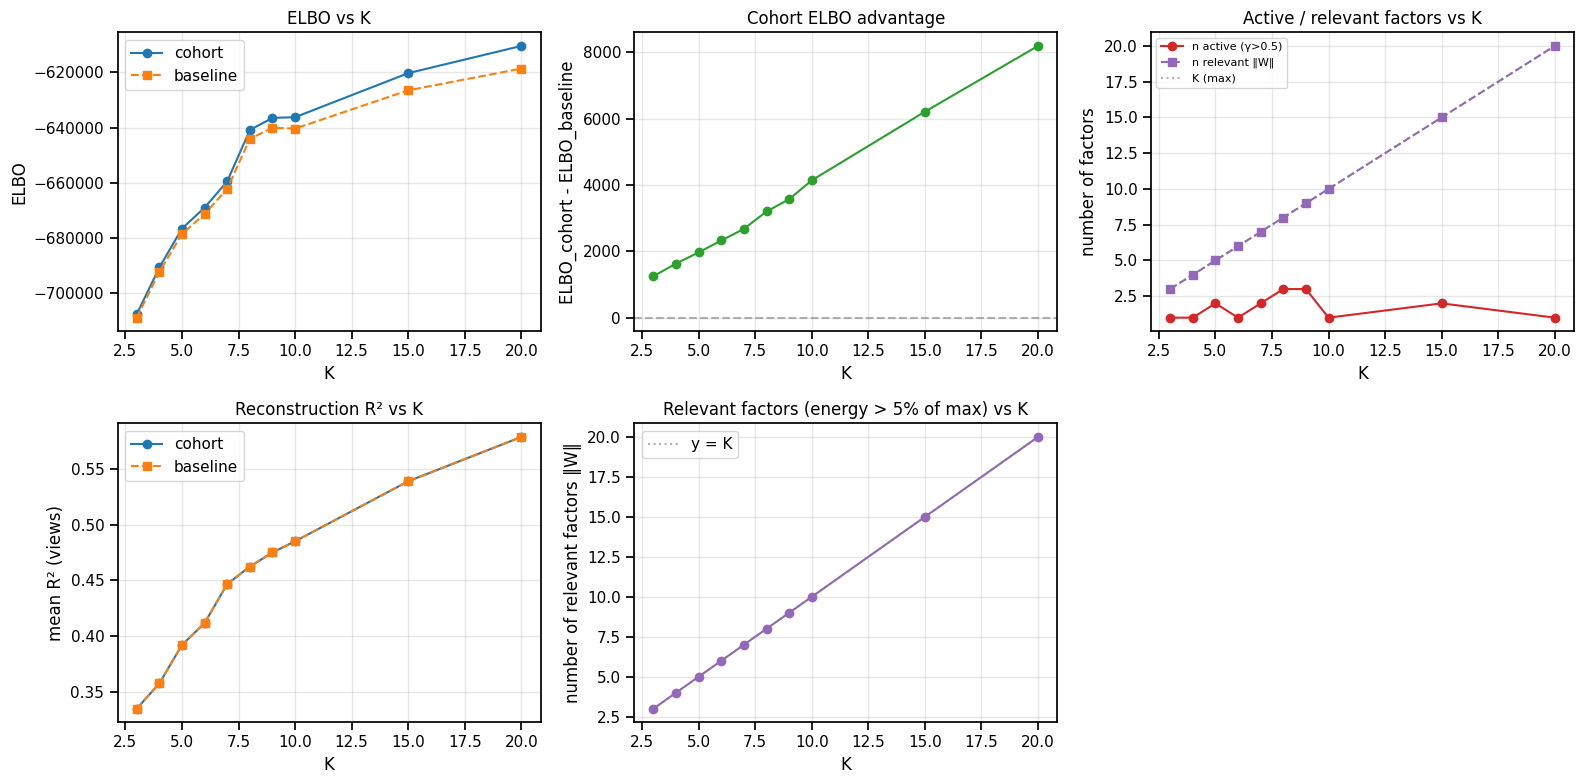

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].plot(df_K['K'], df_K['elbo_cohort'],   'o-', label='cohort')
axes[0, 0].plot(df_K['K'], df_K['elbo_baseline'], 's--', label='baseline')
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('ELBO'); axes[0, 0].set_title('ELBO vs K')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(df_K['K'], df_K['elbo_gap'], 'o-', color='C2')
axes[0, 1].axhline(0, color='gray', ls='--', alpha=0.6)
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('ELBO_cohort - ELBO_baseline')
axes[0, 1].set_title('Cohort ELBO advantage'); axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(df_K['K'], df_K['n_active'], 'o-', color='C3', label='n active (γ>0.5)')
axes[0, 2].plot(df_K['K'], df_K['n_relevant_W'], 's--', color='C4', label='n relevant ‖W‖')
axes[0, 2].plot(df_K['K'], df_K['K'], ':', color='gray', alpha=0.6, label='K (max)')
axes[0, 2].set_xlabel('K'); axes[0, 2].set_ylabel('number of factors')
axes[0, 2].set_title('Active / relevant factors vs K'); axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(df_K['K'], df_K['R2_cohort'],   'o-', label='cohort')
axes[1, 0].plot(df_K['K'], df_K['R2_baseline'], 's--', label='baseline')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('mean R² (views)')
axes[1, 0].set_title('Reconstruction R² vs K')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(df_K['K'], df_K['n_relevant_W'], 'o-', color='C4')
axes[1, 1].plot(df_K['K'], df_K['K'], ':', color='gray', alpha=0.6, label='y = K')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('number of relevant factors ‖W‖')
axes[1, 1].set_title('Relevant factors (energy > 5% of max) vs K')
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# Plot ELBO per iteration for K=5 only (slice from `start_iter`)
K_plot = 5
start_iter = 1  # 1-based; change to plot from a later iteration

mc = get_fit('per_severity', 'cohort', K=K_plot)
mbk = get_fit('per_severity', 'baseline', K=K_plot)

elbo_c = np.asarray(mc.elbo_sequence)
elbo_b = np.asarray(mbk.elbo_sequence)
iters = np.arange(1, len(elbo_c) + 1)

mask = iters >= start_iter

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(iters[mask], elbo_c[mask], '-o', label=f'cohort K={K_plot}', color='C0')
ax.plot(iters[mask], elbo_b[mask], '-s', label=f'baseline K={K_plot}', color='C1')
ax.set_xlabel('iteration')
ax.set_ylabel('ELBO')
ax.set_title(f'ELBO per iteration (per_severity), K={K_plot}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

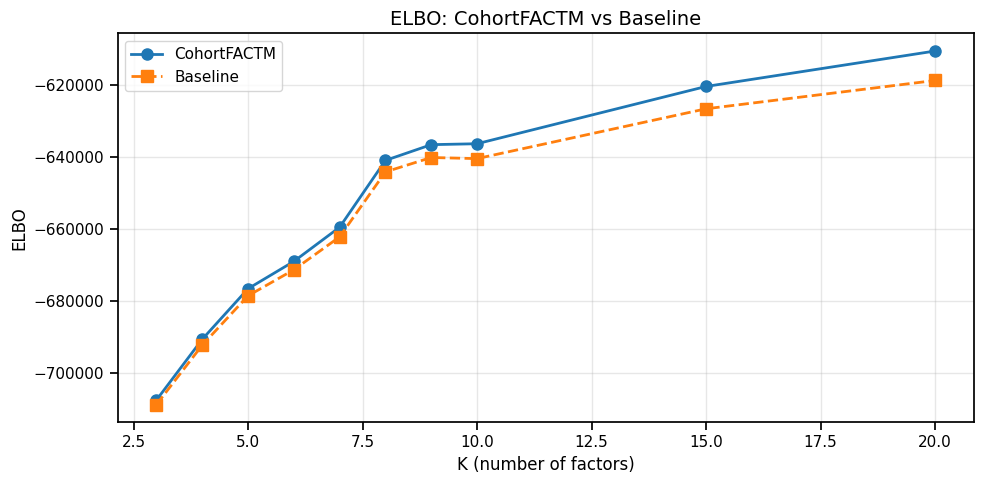

Cohort ELBO above baseline indicates the prior helps; only a few cohort
factors stay active and R² plateaus with `K`.

## 3 — Experiment 2: `grouped` (mild / moderate / severe)
Clinical binning of WHO that balances cohort sizes.

ELBO  cohort=-676305   baseline=-678492


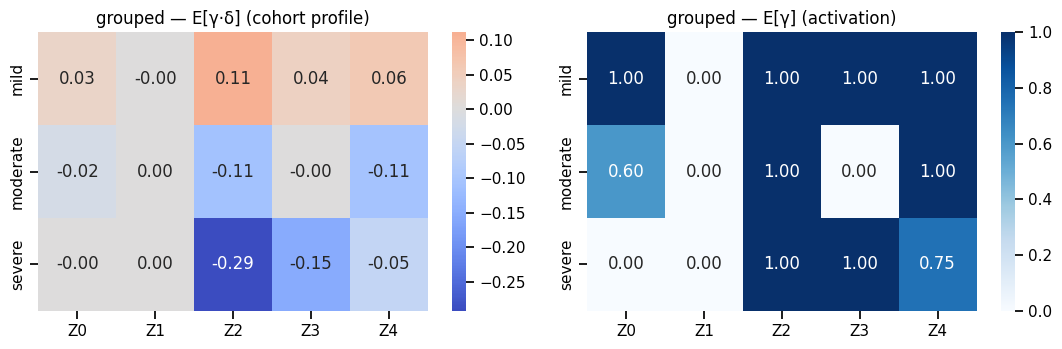

In [12]:
mode = 'grouped'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'grouped')

## 4 — Experiment 3: `binary` (non_hosp / hosp)
Split at WHO = 3 — the simplest case/control partition.

ELBO  cohort=-676291   baseline=-678492


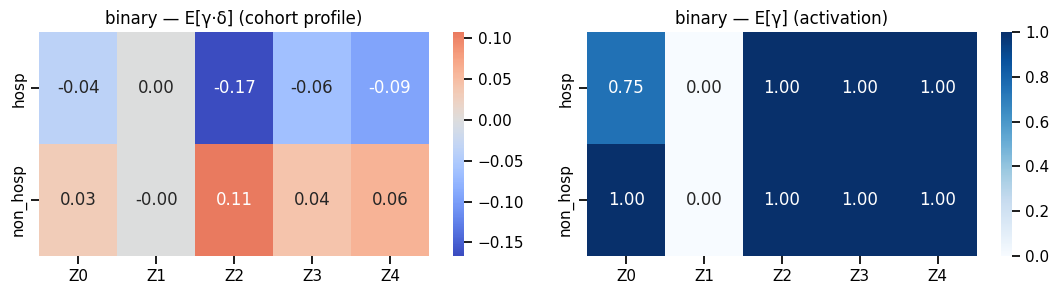

In [13]:
mode = 'binary'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'binary')

## 5 — Experiments 4–5: cohort distances and severity correlation
L2 distances between cohort `E[γ·δ]` positions, and their Spearman correlation
with the WHO gradient (cohort vs baseline).

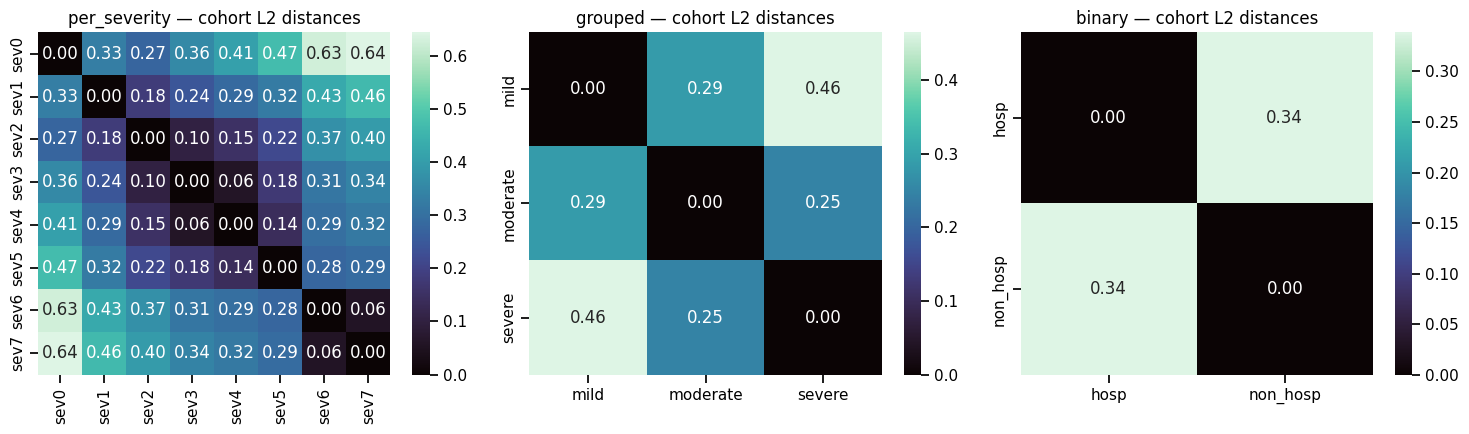

In [14]:
# Exp 4 — L2 distance heatmaps for the three partitions
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mode in zip(axes, ['per_severity', 'grouped', 'binary']):
    m = get_fit(mode, 'cohort', K=HEADLINE_K)
    out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
    M = out['E_gamma'] * out['E_delta']
    D = cohort_dist(M)
    sns.heatmap(D, annot=True, fmt='.2f', cmap='mako',
                xticklabels=out['cohorts'], yticklabels=out['cohorts'], ax=ax)
    ax.set_title(f'{mode} — cohort L2 distances')
plt.tight_layout(); plt.show()

In [15]:
# Exp 5 — distance vs |WHO severity difference| correlation, cohort vs baseline
rows = []
for mode in ['grouped', 'per_severity']:
    mc = get_fit(mode, 'cohort',   K=HEADLINE_K)
    mb = get_fit(mode, 'baseline', K=HEADLINE_K)
    d  = get_data(mode)
    out = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
    names = out['cohorts']

    D_fit = cohort_dist(out['E_gamma'] * out['E_delta'])                 # cohort
    Zh = mb.get_latent_factors()
    Z_means = np.array([Zh[d.cohorts == c].mean(axis=0) for c in names])
    D_base = cohort_dist(Z_means)                                        # baseline

    sev = np.array([severity_from_label(c) for c in names])
    D_sev = np.abs(sev[:, None] - sev[None, :])
    tri = np.triu_indices(len(names), 1)
    r_c = float(spearmanr(D_fit[tri],  D_sev[tri])[0])   # Spearman: D_sev from WHO levels
    r_b = float(spearmanr(D_base[tri], D_sev[tri])[0])
    rows.append({'mode': mode, 'n_cohorts': len(names),
                 'corr_cohort': r_c, 'corr_baseline': r_b,
                 'gap (cohort-baseline)': r_c - r_b})
print(pd.DataFrame(rows).round(3).to_string(index=False))

        mode  n_cohorts  corr_cohort  corr_baseline  gap (cohort-baseline)
     grouped          3         0.50          0.500                  0.000
per_severity          8         0.87          0.714                  0.156


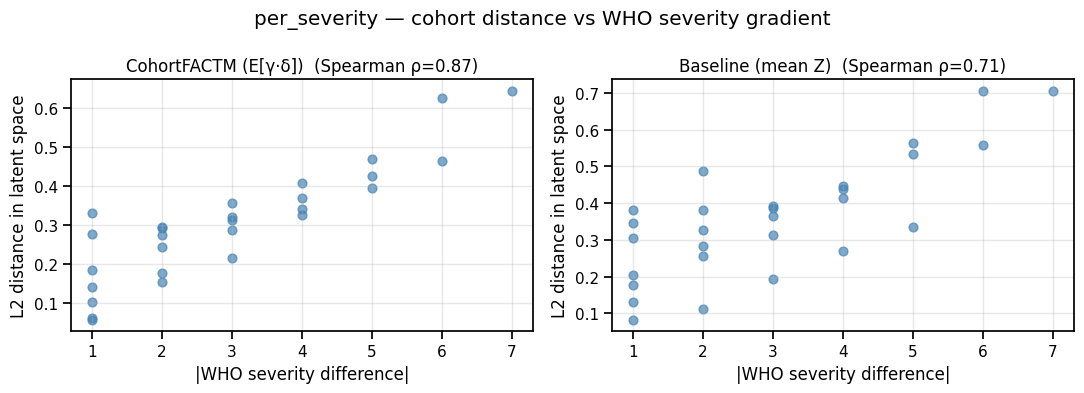

In [16]:
# Scatter: latent distance vs |severity difference| (per_severity), cohort vs baseline
mode = 'per_severity'
mc = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
d  = get_data(mode)
out = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
names = out['cohorts']

D_c = cohort_dist(out['E_gamma'] * out['E_delta'])
Z_means = np.array([mb.get_latent_factors()[d.cohorts == c].mean(axis=0) for c in names])
D_b = cohort_dist(Z_means)
sev = np.array([severity_from_label(c) for c in names])
D_sev = np.abs(sev[:, None] - sev[None, :])
tri = np.triu_indices(len(names), 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, D_fit, label in zip(axes, [D_c, D_b], ['CohortFACTM (E[γ·δ])', 'Baseline (mean Z)']):
    r = float(spearmanr(D_fit[tri], D_sev[tri])[0])
    ax.scatter(D_sev[tri], D_fit[tri], s=40, alpha=0.7, color='steelblue')
    ax.set_xlabel('|WHO severity difference|'); ax.set_ylabel('L2 distance in latent space')
    ax.set_title(f'{label}  (Spearman ρ={r:.2f})'); ax.grid(alpha=0.3)
plt.suptitle('per_severity — cohort distance vs WHO severity gradient')
plt.tight_layout(); plt.show()

At `pi=0.5` the cohort model tracks the WHO gradient better than the
baseline on `per_severity`; `grouped` has too few cohorts to tell apart.

## 6 — `pi` sweep for `K ∈ {3, 5, 10}`
`pi = P(γ = 1)` controls how readily a factor is deemed cohort-discriminating.
Per `(K, pi)` we collect mean `E[γ]`, the number of active factors, and ELBO.

In [17]:
PI_GRID = [0.1, 0.3, 0.5, 0.7, 0.9]
K_FOR_PI = [3, 5, 10]
mode = 'per_severity'
ACTIVE_THR = 0.5

rows = []
gamma_maps = {}   # K -> (n_factors, n_pi) macierz mean E[gamma]
for K in K_FOR_PI:
    cols = []
    for pi in PI_GRID:
        mp = get_fit(mode, 'cohort', K=K, pi=pi)
        E_g, _ = cohort_gamma_delta(mp, K)
        g_mean = E_g.mean(axis=0)
        cols.append(g_mean)
        rows.append({'K': K, 'pi': pi,
                     'n_active': int((g_mean > ACTIVE_THR).sum()),
                     'max_mean_gamma': float(g_mean.max()),
                     'elbo': float(mp.elbo_sequence[-1])})
    gamma_maps[K] = np.array(cols).T   # (K, len(PI_GRID))
df_pi = pd.DataFrame(rows)
print(df_pi.round(3).to_string(index=False))

 K  pi  n_active  max_mean_gamma        elbo
 3 0.1         0           0.002 -707568.843
 3 0.3         0           0.015 -707574.497
 3 0.5         1           0.732 -707498.723
 3 0.7         3           0.867 -707497.661
 3 0.9         3           0.961 -707494.839
 5 0.1         0           0.003 -676649.877
 5 0.3         0           0.399 -676521.530
 5 0.5         2           0.783 -676522.292
 5 0.7         5           0.877 -676534.069
 5 0.9         5           0.962 -676531.901
10 0.1         0           0.002 -636260.052
10 0.3         0           0.273 -636193.818
10 0.5         1           0.846 -636201.149
10 0.7        10           0.920 -636251.159
10 0.9        10           0.975 -636250.329


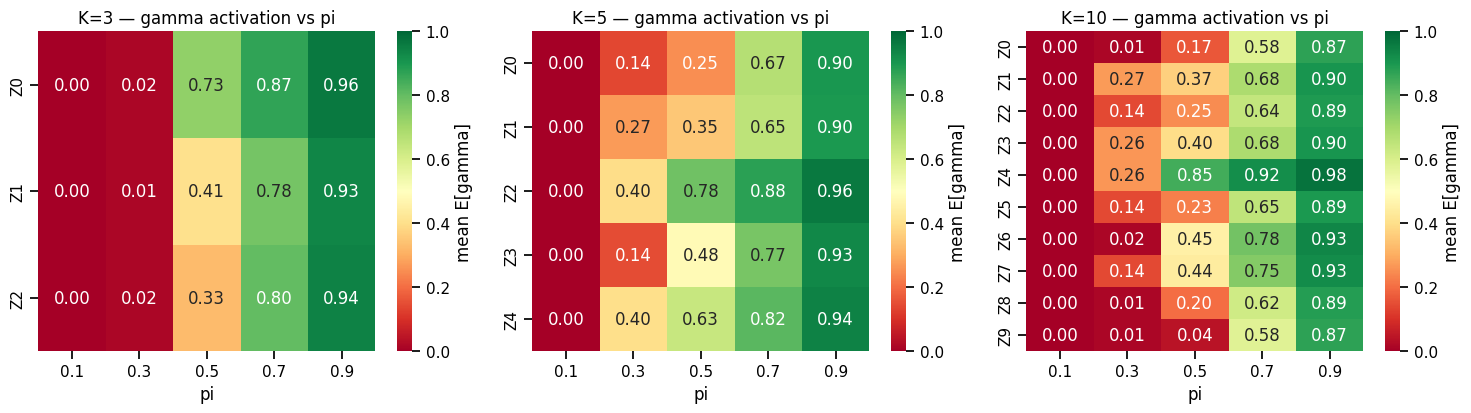

In [18]:
# Gamma activation maps (factor x pi) for each K
fig, axes = plt.subplots(1, len(K_FOR_PI), figsize=(5 * len(K_FOR_PI), 0.8 + 0.35 * max(K_FOR_PI)))
for ax, K in zip(axes, K_FOR_PI):
    sns.heatmap(gamma_maps[K], annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
                xticklabels=[f'{p:g}' for p in PI_GRID],
                yticklabels=[f'Z{k}' for k in range(K)],
                cbar_kws={'label': 'mean E[gamma]'}, ax=ax)
    ax.set_xlabel('pi'); ax.set_title(f'K={K} — gamma activation vs pi')
plt.tight_layout(); plt.show()

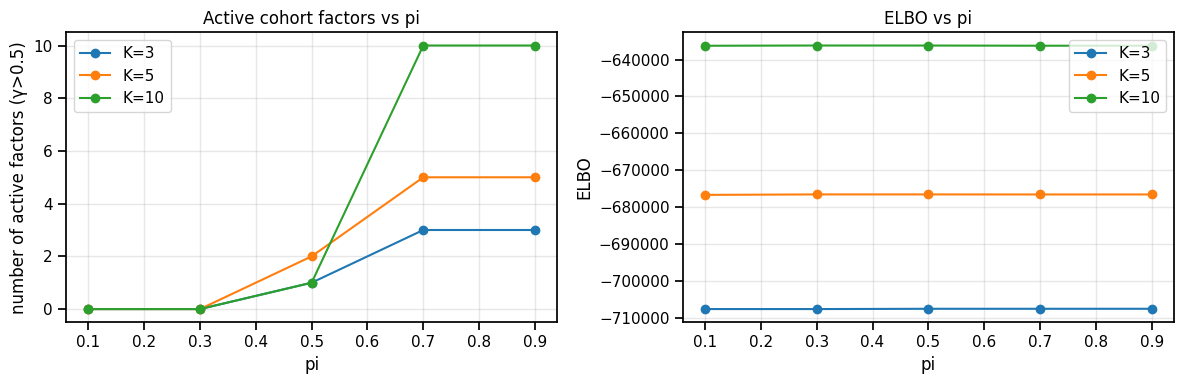

In [19]:
# n_active i ELBO vs pi dla trzech K
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for K in K_FOR_PI:
    sub = df_pi[df_pi['K'] == K]
    axes[0].plot(sub['pi'], sub['n_active'], 'o-', label=f'K={K}')
    axes[1].plot(sub['pi'], sub['elbo'],     'o-', label=f'K={K}')
axes[0].set_xlabel('pi'); axes[0].set_ylabel('number of active factors (γ>0.5)')
axes[0].set_title('Active cohort factors vs pi'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('pi'); axes[1].set_ylabel('ELBO')
axes[1].set_title('ELBO vs pi'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Strong cohort factors stay active across `pi`; silent ones activate only
at large `pi`. The sweet spot is around `0.3–0.5`.

### 6b — Choosing `pi`: 0.3 vs 0.5 vs 0.7
Justifies `pi=0.5` via the `E[γ·δ]` profile, the WHO correlation, and cohort
recovery.

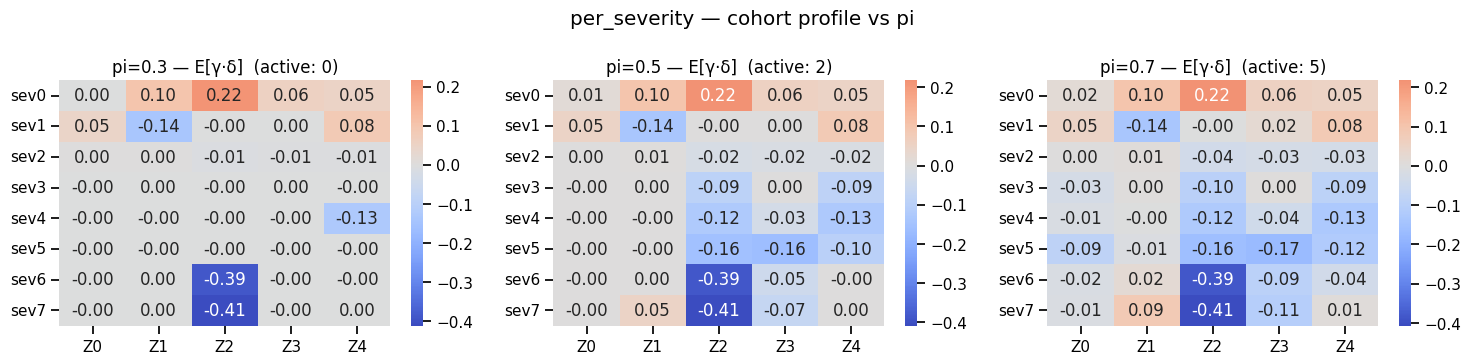

In [20]:
# 6b-1 — profil E[γ·δ] dla per_severity przy pi = 0.3 / 0.5 / 0.7
PIS = [0.3, 0.5, 0.7]
mode = 'per_severity'
d = get_data(mode)
names = np.array(sorted(np.unique(d.cohorts)))
fig, axes = plt.subplots(1, len(PIS), figsize=(5 * len(PIS), 0.5 + 0.4 * len(names)))
for ax, pi in zip(axes, PIS):
    m = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi)
    E_g, E_d = cohort_gamma_delta(m, HEADLINE_K)
    n_act = int((E_g.mean(0) > 0.5).sum())
    sns.heatmap(E_g * E_d, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                xticklabels=[f'Z{k}' for k in range(HEADLINE_K)], yticklabels=names, ax=ax)
    ax.set_title(f'pi={pi} — E[γ·δ]  (active: {n_act})')
plt.suptitle('per_severity — cohort profile vs pi')
plt.tight_layout(); plt.show()

In [21]:
# 6b-2 — cohort distance vs WHO severity correlation at pi = 0.3 / 0.5 / 0.7
PIS = [0.3, 0.5, 0.7]
rows = []
for mode in ['grouped', 'per_severity']:
    d = get_data(mode)
    names = np.array(sorted(np.unique(d.cohorts)))
    sev = np.array([severity_from_label(c) for c in names])
    D_sev = np.abs(sev[:, None] - sev[None, :])
    tri = np.triu_indices(len(names), 1)
    Zb = get_fit(mode, 'baseline', K=HEADLINE_K).get_latent_factors()
    Zmb = np.array([Zb[d.cohorts == c].mean(0) for c in names])
    row = {'mode': mode, 'baseline': round(float(spearmanr(cohort_dist(Zmb)[tri], D_sev[tri])[0]), 3)}
    for pi in PIS:
        m = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi)
        E_g, E_d = cohort_gamma_delta(m, HEADLINE_K)
        D = cohort_dist(E_g * E_d)
        row[f'cohort_pi{pi}'] = round(float(spearmanr(D[tri], D_sev[tri])[0]), 3)
    rows.append(row)
print('Cohort distance vs |WHO difference| correlation (higher = better):')
print(pd.DataFrame(rows).to_string(index=False))

Cohort distance vs |WHO difference| correlation (higher = better):
        mode  baseline  cohort_pi0.3  cohort_pi0.5  cohort_pi0.7
     grouped     0.500           0.5          0.50         0.500
per_severity     0.714           0.6          0.87         0.886


In [22]:
# 6b-3 — odzysk kohort (k-means, k = liczba kohort) przy pi = 0.3 / 0.5 / 0.7
PIS = [0.3, 0.5, 0.7]
rows = []
for mode in ['per_severity', 'grouped', 'binary']:
    d = get_data(mode)
    _, codes = np.unique(d.cohorts, return_inverse=True)
    C = len(np.unique(codes))
    labb = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(
        get_fit(mode, 'baseline', K=HEADLINE_K).get_latent_factors())
    row = {'mode': mode, 'baseline_ARI': round(adjusted_rand_score(codes, labb), 3)}
    for pi in PIS:
        lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(
            get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi).get_latent_factors())
        row[f'cohort_pi{pi}_ARI'] = round(adjusted_rand_score(codes, lab), 3)
    rows.append(row)
print('Cohort recovery from Z_hat (ARI, higher = better):')
print(pd.DataFrame(rows).to_string(index=False))

Cohort recovery from Z_hat (ARI, higher = better):
        mode  baseline_ARI  cohort_pi0.3_ARI  cohort_pi0.5_ARI  cohort_pi0.7_ARI
per_severity         0.554             0.553             0.555             0.555
     grouped         0.557             0.554             0.554             0.554
      binary         0.611             0.003             0.003             0.003


`pi=0.5` is a good compromise: cohort factors switch on and the WHO
gradient is recovered, without activating every factor as at `0.7`.

## 7 — Structure of the `Z` factors
Latent space (`per_severity`, K=5): factor correlations, which factors are alive
and encode severity, and cohort centroids.

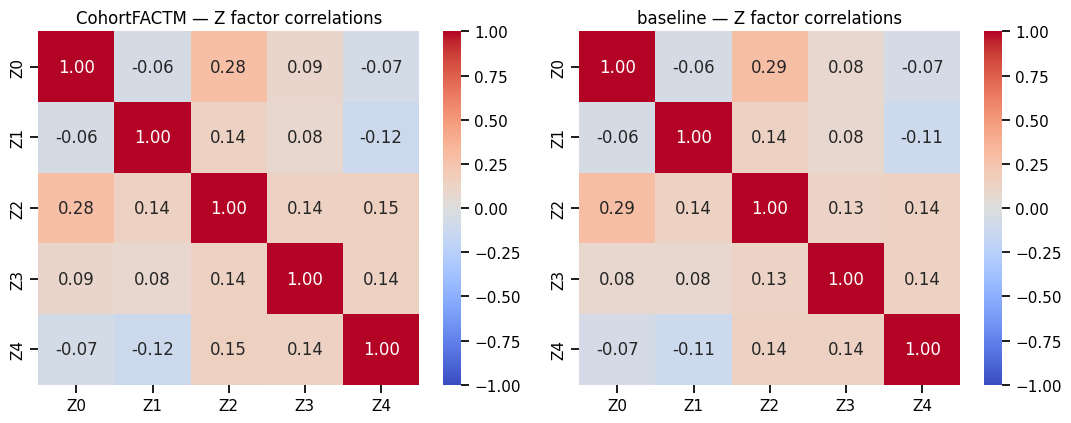

In [23]:
# 7a — correlations between Z factors: cohort vs baseline
mode = 'per_severity'
mc = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
d = get_data(mode)
factors = [f'Z{k}' for k in range(HEADLINE_K)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (mdl, name) in zip(axes, [(mc, 'CohortFACTM'), (mb, 'baseline')]):
    sns.heatmap(np.corrcoef(mdl.get_latent_factors().T), annot=True, fmt='.2f',
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                xticklabels=factors, yticklabels=factors, ax=ax)
    ax.set_title(f'{name} — Z factor correlations')
plt.tight_layout(); plt.show()

WHO correlations use Spearman (the scale is ordinal); factor↔factor
correlations stay Pearson.

    var(Z[:,k])  ‖W0[:,k]‖ (energia)  |ρ(Z, WHO)| Spearman
Z0        0.043               53.421                 0.207
Z1        0.024               22.513                 0.164
Z2        0.051               35.308                 0.833
Z3        0.023               38.458                 0.668
Z4        0.023               59.642                 0.446

Factor most associated with WHO severity: Z2  (|corr|=0.833)


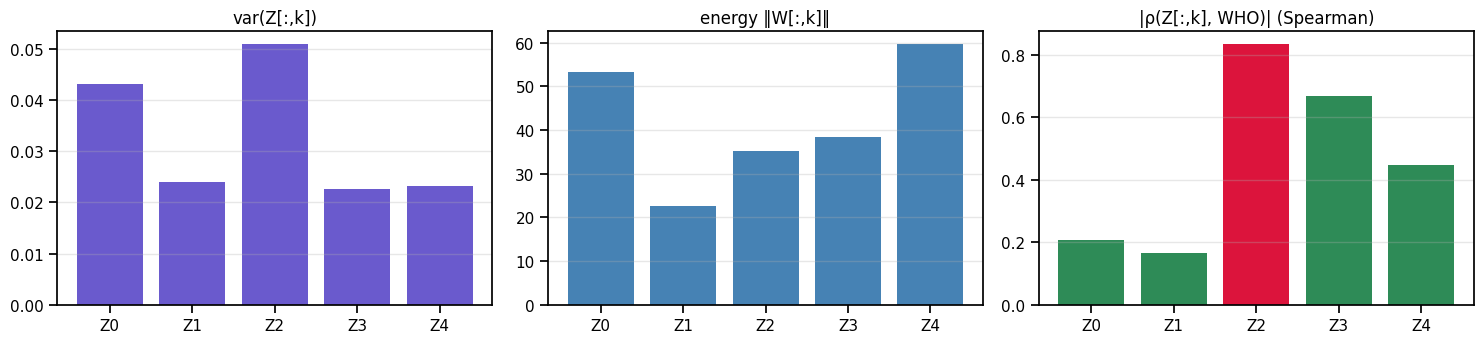

In [24]:
# 7b — factor relevance and association with WHO severity (cohort model)
Z = mc.get_latent_factors()
energy = np.linalg.norm(get_W(mc, 0), axis=0)
zvar = Z.var(0)
sev = d.severity.astype(float)
fac_sev = np.array([abscorr_spear(Z[:, k], sev) for k in range(HEADLINE_K)])  # Spearman: WHO ordinalne

tab = pd.DataFrame({'var(Z[:,k])': zvar.round(3),
                    '‖W0[:,k]‖ (energia)': energy.round(3),
                    '|ρ(Z, WHO)| Spearman': fac_sev.round(3)}, index=factors)
print(tab.to_string())
print(f'\nFactor most associated with WHO severity: '
      f'{factors[int(np.nanargmax(fac_sev))]}  (|corr|={np.nanmax(fac_sev):.3f})')

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].bar(factors, zvar, color='slateblue');  axes[0].set_title('var(Z[:,k])')
axes[1].bar(factors, energy, color='steelblue'); axes[1].set_title('energy ‖W[:,k]‖')
colors = ['crimson' if k == int(np.nanargmax(fac_sev)) else 'seagreen' for k in range(HEADLINE_K)]
axes[2].bar(factors, fac_sev, color=colors);     axes[2].set_title('|ρ(Z[:,k], WHO)| (Spearman)')
for ax in axes:
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

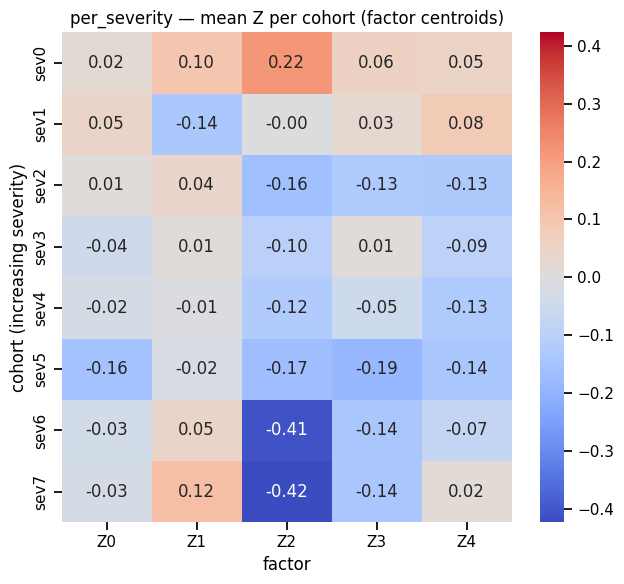

In [25]:
# 7c — cohort centroids in factor space (mean Z per cohort)
names, codes = np.unique(d.cohorts, return_inverse=True)
cent = np.array([Z[codes == i].mean(0) for i in range(len(names))])
vmax = np.abs(cent).max()
fig, ax = plt.subplots(figsize=(6.5, 0.5 * len(names) + 2))
sns.heatmap(cent, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=factors, yticklabels=names, ax=ax)
ax.set_title('per_severity — mean Z per cohort (factor centroids)')
ax.set_xlabel('factor'); ax.set_ylabel('cohort (increasing severity)')
plt.tight_layout(); plt.show()

Small off-diagonal = independent factors. The factor with high
`|ρ(Z, WHO)|` is the severity axis; near-zero-energy factors were pruned by
ARD.

## 8 — Clustering and separation metrics
Do cohorts separate in `Z_hat`? Internal metrics (silhouette, Calinski-Harabasz,
Davies-Bouldin) and external ones vs true labels (ARI, NMI, AMI, V-measure,
FMI), cohort vs baseline.

In [26]:
# 8a — metryki separacji Z_hat: cohort vs baseline, dla trzech partycji
rows = []
for mode in ['per_severity', 'grouped', 'binary']:
    d = get_data(mode)
    codes = np.unique(d.cohorts, return_inverse=True)[1]
    for kind in ['cohort', 'baseline']:
        m = get_fit(mode, kind, K=HEADLINE_K)
        mets = clustering_metrics(m.get_latent_factors(), codes)
        rows.append({'mode': mode, 'model': kind, **{k: round(v, 3) for k, v in mets.items()}})
df_sep = pd.DataFrame(rows)
print(df_sep.to_string(index=False))

        mode    model  silhouette  davies_bouldin  calinski_harabasz  within/between
per_severity   cohort       0.174           4.457             28.830           0.786
per_severity baseline       0.169           4.457             28.725           0.790
     grouped   cohort       0.209           2.323             55.591           0.832
     grouped baseline       0.206           2.352             55.377           0.844
      binary   cohort       0.277           1.554             89.464           0.777
      binary baseline       0.273           1.578             88.727           0.789


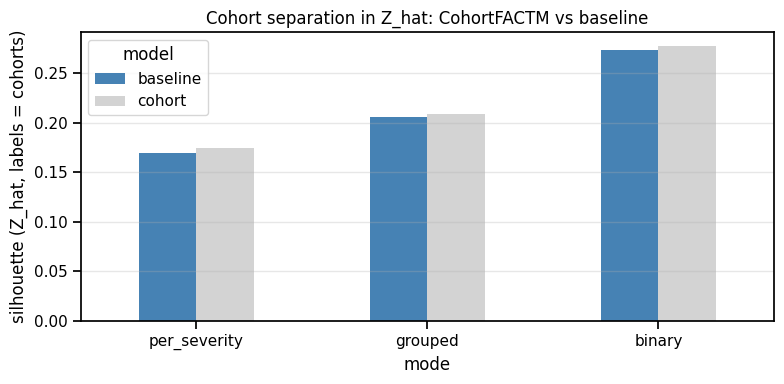

In [27]:
# 8b — silhouette comparison (cohort vs baseline) per partition
piv = df_sep.pivot(index='mode', columns='model', values='silhouette').loc[
    ['per_severity', 'grouped', 'binary']]
ax = piv.plot.bar(figsize=(8, 4), color=['steelblue', 'lightgray'], rot=0)
ax.set_ylabel('silhouette (Z_hat, labels = cohorts)')
ax.set_title('Cohort separation in Z_hat: CohortFACTM vs baseline')
ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

Cohort-level clustering (D_fit, per_severity):
       method  k  silhouette
agglomerative  2       0.329
       kmeans  2       0.482
     spectral  2       0.482
agglomerative  3       0.448
       kmeans  3       0.448
     spectral  3       0.408
agglomerative  4       0.414
       kmeans  4       0.414
     spectral  4       0.414


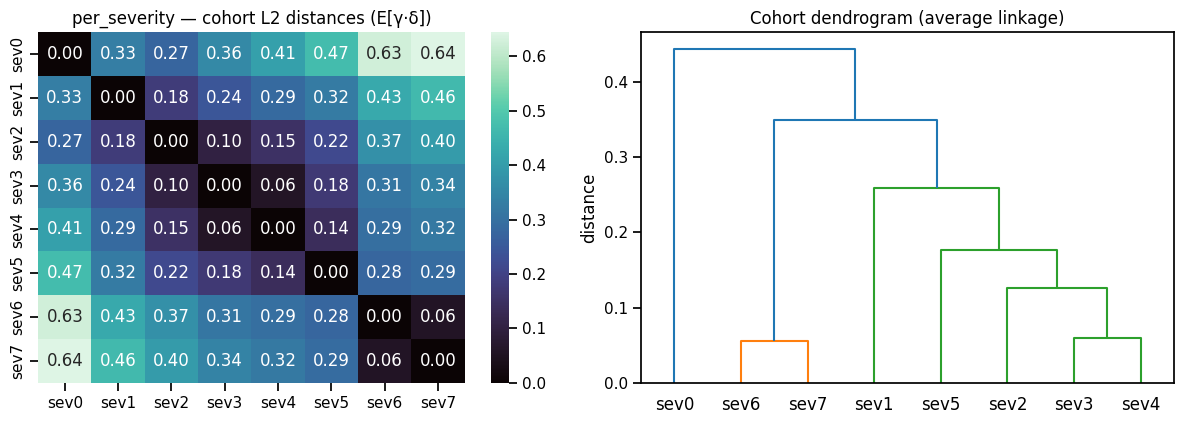

In [28]:
# 8c — cohort-level clustering (per_severity): E[γ·δ] distance matrix
mode = 'per_severity'
mc = get_fit(mode, 'cohort', K=HEADLINE_K)
d = get_data(mode)
out = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
names = out['cohorts']
M_fit = out['E_gamma'] * out['E_delta']
D_fit = cohort_dist(M_fit)

df_cc, labels_cc = cluster_cohorts(D_fit, k_range=(2, 3, 4))
print('Cohort-level clustering (D_fit, per_severity):')
print(df_cc.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.heatmap(D_fit, annot=True, fmt='.2f', cmap='mako',
            xticklabels=names, yticklabels=names, ax=axes[0])
axes[0].set_title('per_severity — cohort L2 distances (E[γ·δ])')
Zlink = linkage(squareform(D_fit, checks=False), method='average')
dendrogram(Zlink, labels=list(names), ax=axes[1],
           color_threshold=0.7 * Zlink[:, 2].max())
axes[1].set_title('Cohort dendrogram (average linkage)'); axes[1].set_ylabel('distance')
plt.tight_layout(); plt.show()

Per-partition comparison (k-means, k = number of cohorts):
        mode    model  k        ELBO    R2  silhouette   ARI   NMI   AMI  V_measure   FMI
per_severity   cohort  8 -676522.292 0.392       0.174 0.555 0.506 0.487      0.506 0.648
per_severity baseline  8 -678491.713 0.392       0.169 0.554 0.504 0.485      0.504 0.647
     grouped   cohort  3 -676305.355 0.392       0.209 0.554 0.460 0.456      0.460 0.772
     grouped baseline  3 -678491.713 0.392       0.206 0.557 0.461 0.458      0.461 0.774
      binary   cohort  2 -676290.698 0.392       0.277 0.003 0.007 0.002      0.007 0.722
      binary baseline  2 -678491.713 0.392       0.273 0.611 0.491 0.490      0.491 0.816

Difference cohort - baseline (positive = cohort better):
        mode    ΔELBO  ΔR2  Δsilhouette   ΔARI   ΔNMI   ΔAMI  ΔV_measure   ΔFMI
per_severity 1969.421 -0.0        0.005  0.001  0.002  0.002       0.002  0.001
     grouped 2186.358 -0.0        0.003 -0.003 -0.002 -0.002      -0.002 -0.002
      binary 

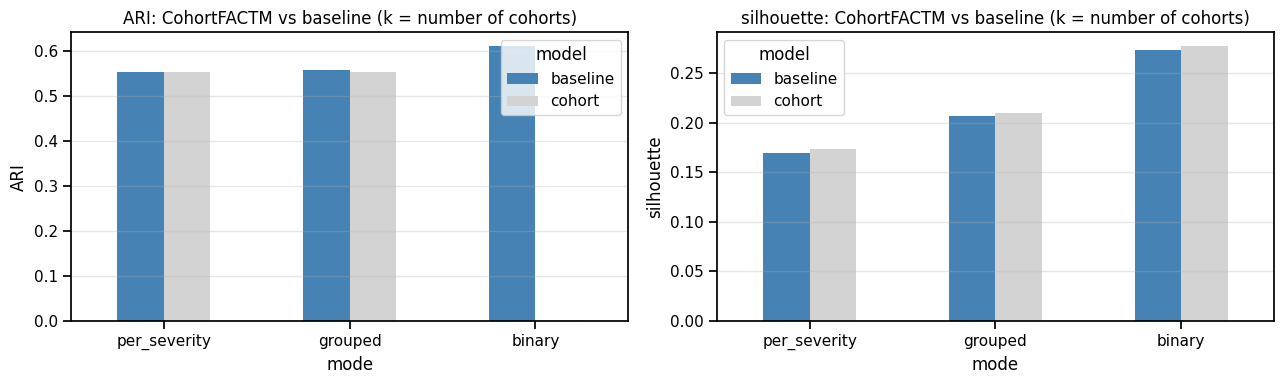

In [29]:
# 8d — Full baseline vs cohort comparison + cohort recovery.
# We cluster Z_hat WITHOUT labels via k-means with k = number of cohorts and compare recovery
# (ARI/NMI/AMI/V/FMI) z metrykami dopasowania (ELBO, R²) oraz separacji (silhouette
# (vs true cohorts). One table = full comparison of both models per partition.
rows = []
for mode in ['per_severity', 'grouped', 'binary']:
    d = get_data(mode)
    views = d.views
    _, codes = np.unique(d.cohorts, return_inverse=True)
    C = len(np.unique(codes))                       # k-means: k = liczba kohort
    for kind in ['cohort', 'baseline']:
        m = get_fit(mode, kind, K=HEADLINE_K)
        Z = m.get_latent_factors()
        lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Z)
        h, comp, v = homogeneity_completeness_v_measure(codes, lab)
        rows.append({'mode': mode, 'model': kind, 'k': C,
                     'ELBO': float(m.elbo_sequence[-1]),
                     'R2': mean_r2(m, views),
                     'silhouette': float(silhouette_score(Z, codes)),
                     'ARI': adjusted_rand_score(codes, lab),
                     'NMI': normalized_mutual_info_score(codes, lab),
                     'AMI': adjusted_mutual_info_score(codes, lab),
                     'V_measure': v,
                     'FMI': fowlkes_mallows_score(codes, lab)})
df_rec = pd.DataFrame(rows)
print('Per-partition comparison (k-means, k = number of cohorts):')
print(df_rec.round(3).to_string(index=False))

# Difference cohort - baseline per metric (here all: higher = better)
metr = ['ELBO', 'R2', 'silhouette', 'ARI', 'NMI', 'AMI', 'V_measure', 'FMI']
gap = []
for mode in ['per_severity', 'grouped', 'binary']:
    sub = df_rec[df_rec['mode'] == mode].set_index('model')
    gap.append({'mode': mode,
                **{f'Δ{x}': round(float(sub.loc['cohort', x] - sub.loc['baseline', x]), 3)
                   for x in metr}})
df_gap = pd.DataFrame(gap)
print('\nDifference cohort - baseline (positive = cohort better):')
print(df_gap.to_string(index=False))

# Wykres: ARI i silhouette obok siebie, cohort vs baseline, per partycja
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ['ARI', 'silhouette']):
    piv = df_rec.pivot(index='mode', columns='model', values=metric).loc[
        ['per_severity', 'grouped', 'binary']]
    piv.plot.bar(ax=ax, color=['steelblue', 'lightgray'], rot=0)
    ax.set_ylabel(metric); ax.set_title(f'{metric}: CohortFACTM vs baseline (k = number of cohorts)')
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

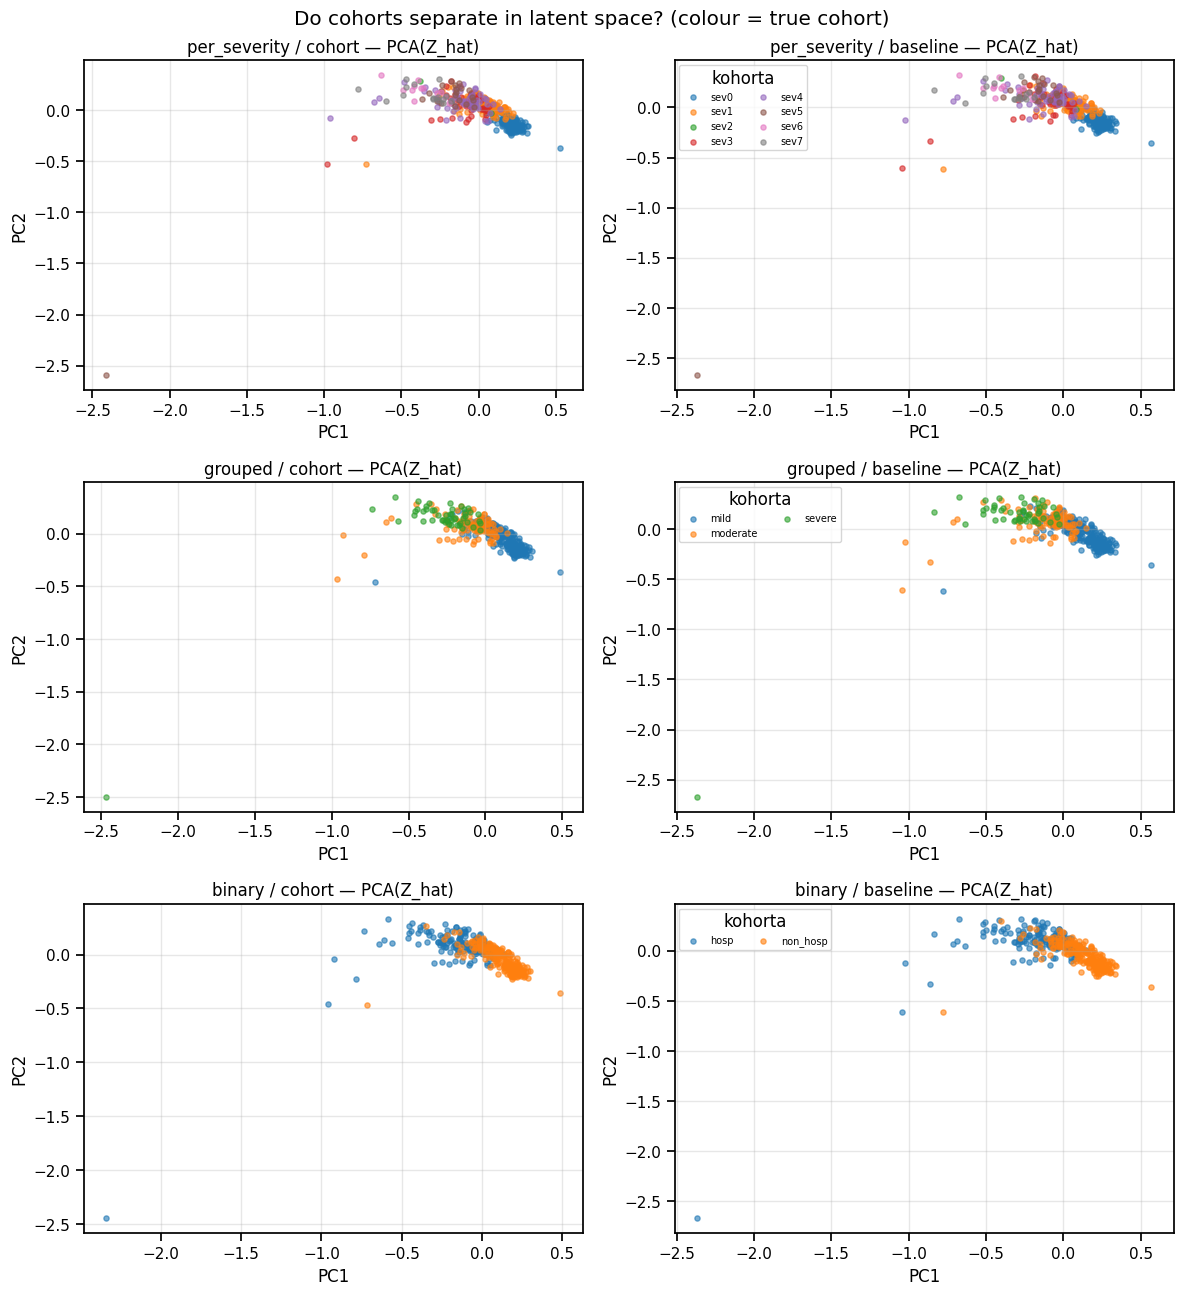

In [30]:
# 8e — visual check: do cohorts form clusters in Z_hat? PCA cohort vs baseline (3 partitions)
modes = ['per_severity', 'grouped', 'binary']
fig, axes = plt.subplots(len(modes), 2, figsize=(12, 4.4 * len(modes)))
for r, mode in enumerate(modes):
    d = get_data(mode)
    names, codes = np.unique(d.cohorts, return_inverse=True)
    for cax, kind in zip(axes[r], ['cohort', 'baseline']):
        Z = get_fit(mode, kind, K=HEADLINE_K).get_latent_factors()
        P = PCA(n_components=2).fit_transform(Z)
        for i, name in enumerate(names):
            msk = codes == i
            cax.scatter(P[msk, 0], P[msk, 1], s=14, alpha=0.6, label=name)
        cax.set_title(f'{mode} / {kind} — PCA(Z_hat)')
        cax.set_xlabel('PC1'); cax.set_ylabel('PC2'); cax.grid(alpha=0.3)
    axes[r, 1].legend(fontsize=7, ncol=2, title='kohorta')
plt.suptitle('Do cohorts separate in latent space? (colour = true cohort)')
plt.tight_layout(); plt.show()

### 8e-bis — Cohort recovery across all `pi`
Clustering metrics from k-means on `Z_hat` for every `pi`.

In [31]:
# 8e-bis — metryki klastrowania (odzysk kohort, k-means k=#kohort) dla WSZYSTKICH pi
# Per-partition comparison as in 8d, but sweeping pi (per_severity, K=5). Reuses fits from sec. 6.
mode = 'per_severity'
d = get_data(mode)
_, codes = np.unique(d.cohorts, return_inverse=True)
C = len(np.unique(codes))
rows = []
for pi in PI_GRID:
    Z = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi).get_latent_factors()
    lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Z)
    h, comp, v = homogeneity_completeness_v_measure(codes, lab)
    rows.append({'pi': pi, 'k': C,
                 'silhouette': float(silhouette_score(Z, codes)),
                 'ARI': float(adjusted_rand_score(codes, lab)),
                 'NMI': float(normalized_mutual_info_score(codes, lab)),
                 'AMI': float(adjusted_mutual_info_score(codes, lab)),
                 'V_measure': float(v),
                 'FMI': float(fowlkes_mallows_score(codes, lab))})
df_pi_clust = pd.DataFrame(rows)
print('Per-pi comparison — cohort recovery (k-means, k = number of cohorts), per_severity:')
print(df_pi_clust.round(3).to_string(index=False))

Per-pi comparison — cohort recovery (k-means, k = number of cohorts), per_severity:
 pi  k  silhouette   ARI   NMI   AMI  V_measure   FMI
0.1  8       0.171 0.553 0.502 0.484      0.502 0.647
0.3  8       0.174 0.553 0.502 0.484      0.502 0.647
0.5  8       0.174 0.555 0.506 0.487      0.506 0.648
0.7  8       0.174 0.555 0.506 0.487      0.506 0.648
0.9  8       0.174 0.555 0.506 0.487      0.506 0.648


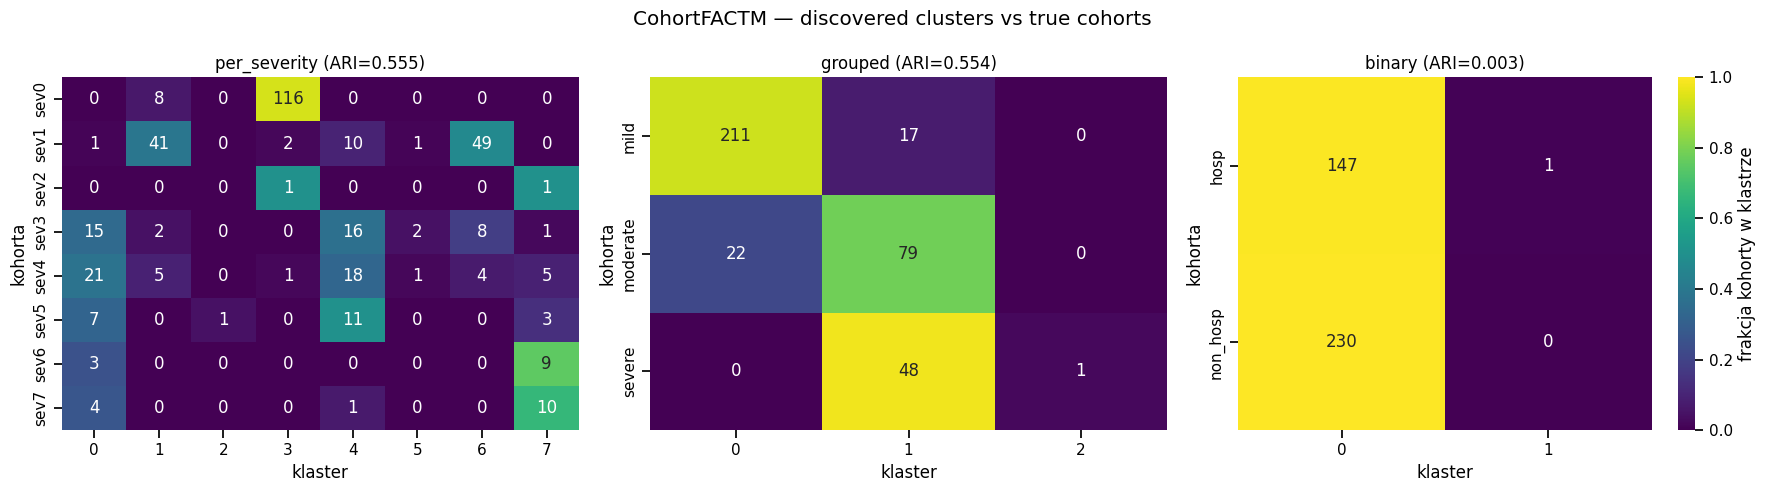

In [32]:
# 8f — agreement matrix: discovered clusters (k-means, k = number of cohorts) vs true cohorts (3 partitions)
modes = ['per_severity', 'grouped', 'binary']
fig, axes = plt.subplots(1, len(modes), figsize=(6 * len(modes), 5))
for ax, mode in zip(axes, modes):
    d = get_data(mode)
    names, codes = np.unique(d.cohorts, return_inverse=True)
    C = len(names)
    Z = get_fit(mode, 'cohort', K=HEADLINE_K).get_latent_factors()
    lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Z)
    ct = pd.crosstab(pd.Series(d.cohorts, name='kohorta'), pd.Series(lab, name='klaster'))
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    sns.heatmap(ct_norm, annot=ct.values, fmt='d', cmap='viridis', vmin=0, vmax=1,
                cbar=(ax is axes[-1]),
                cbar_kws={'label': 'frakcja kohorty w klastrze'}, ax=ax)
    ax.set_title(f'{mode} (ARI={adjusted_rand_score(codes, lab):.3f})')
plt.suptitle('CohortFACTM — discovered clusters vs true cohorts')
plt.tight_layout(); plt.show()

 pi  silhouette  davies_bouldin  calinski_harabasz  within/between
0.1       0.171           4.461             27.776           0.792
0.3       0.174           4.460             28.644           0.788
0.5       0.174           4.457             28.830           0.786
0.7       0.174           4.455             28.843           0.786
0.9       0.174           4.455             28.855           0.786


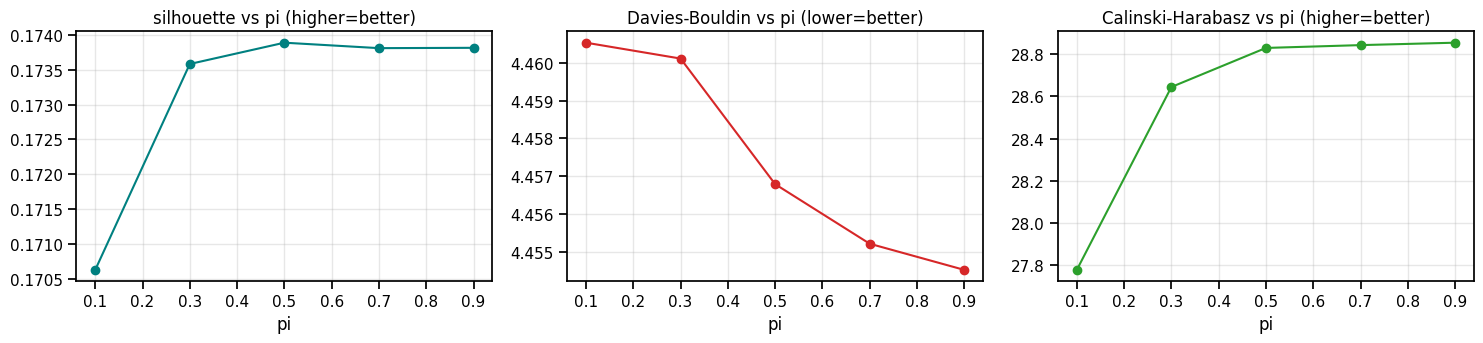

In [33]:
# 8g — how cohort separation depends on pi (per_severity, K=5) — reuses fits from sec. 6
mode = 'per_severity'
codes = np.unique(get_data(mode).cohorts, return_inverse=True)[1]
rows = []
for pi in PI_GRID:
    mp = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi)
    rows.append({'pi': pi, **clustering_metrics(mp.get_latent_factors(), codes)})
df_sil = pd.DataFrame(rows)
print(df_sil.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(df_sil['pi'], df_sil['silhouette'], 'o-', color='teal')
axes[0].set_title('silhouette vs pi (higher=better)')
axes[1].plot(df_sil['pi'], df_sil['davies_bouldin'], 'o-', color='C3')
axes[1].set_title('Davies-Bouldin vs pi (lower=better)')
axes[2].plot(df_sil['pi'], df_sil['calinski_harabasz'], 'o-', color='C2')
axes[2].set_title('Calinski-Harabasz vs pi (higher=better)')
for ax in axes:
    ax.set_xlabel('pi'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

k-means on `Z_hat` vs true cohorts. For the cohort model, cohorts live in
`γ·δ` (sections 2, 5), not in the spread of `Z_hat` — so `binary` recovers worse
there by design.

## 9 — Loadings `W` and factor relevance
Learned loadings `E[W]` (which features build each factor) and ARD relevance,
read from loading energy and ARD precision rather than `E[S]`.

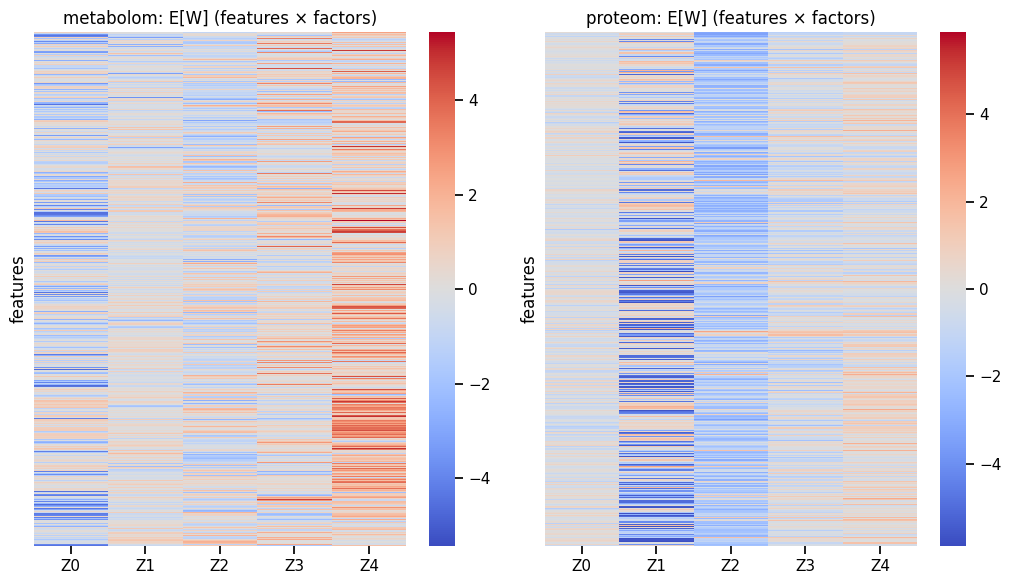

In [34]:
# 9a — learned loadings E[W] per view (per_severity, K=5)
mode = 'per_severity'
mc = get_fit(mode, 'cohort', K=HEADLINE_K)
views = get_data(mode).views
factors = [f'Z{k}' for k in range(HEADLINE_K)]
view_names = ['metabolom', 'proteom']

fig, axes = plt.subplots(1, views.num_simple, figsize=(5.2 * views.num_simple, 6))
for v in range(views.num_simple):
    E_w = get_W(mc, v)
    vmax = np.abs(E_w).max()
    sns.heatmap(E_w, cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
                xticklabels=factors, yticklabels=False, ax=axes[v])
    axes[v].set_title(f'{view_names[v]}: E[W] (features × factors)')
    axes[v].set_ylabel('features')
plt.tight_layout(); plt.show()

In [35]:
# 9c — top features per factor (which metabolites/proteins build it most)
from pathlib import Path
import covid_data.load_covid as _lc

_base = Path(_lc.__file__).resolve().parent
feat_names = {
    'metabolom': pd.read_csv(_base / _lc.METABOLIC_FILE, index_col=0, nrows=0).columns.tolist(),
    'proteom':   pd.read_csv(_base / _lc.PROTEOMIC_FILE, index_col=0, nrows=0).columns.tolist(),
}
TOPN = 10
view_names = ['metabolom', 'proteom']

rows = []
for k in range(HEADLINE_K):
    for v, vname in enumerate(view_names):
        W = get_W(mc, v)                              # (D, K)
        col = W[:, k]
        order_pos = np.argsort(col)[::-1][:TOPN]     # top dodatnie
        order_neg = np.argsort(col)[:TOPN]            # top ujemne
        rows.append({'faktor': f'Z{k}', 'widok': vname, 'kierunek': 'dodatni (+)',
                     **{f'#{i+1}': f'{feat_names[vname][j]} ({col[j]:+.2f})'
                        for i, j in enumerate(order_pos)}})
        rows.append({'faktor': f'Z{k}', 'widok': vname, 'kierunek': 'ujemny (−)',
                     **{f'#{i+1}': f'{feat_names[vname][j]} ({col[j]:+.2f})'
                        for i, j in enumerate(order_neg)}})

df_top = pd.DataFrame(rows).set_index(['faktor', 'widok', 'kierunek'])
# print per factor
for k in range(HEADLINE_K):
    e = np.linalg.norm(get_W(mc, 0)[:, k])
    c = abs(float(np.corrcoef(mc.get_latent_factors()[:, k],
                              get_data('per_severity').severity.astype(float))[0, 1]))
    print(f'\n{"="*70}')
    print(f'FACTOR Z{k}   energy‖W0‖={e:.1f}   |corr with WHO|={c:.3f}')
    print(f'{"="*70}')
    for v, vname in enumerate(view_names):
        W = get_W(mc, v)
        col = W[:, k]
        pos = np.argsort(col)[::-1][:TOPN]
        neg = np.argsort(col)[:TOPN]
        print(f'\n  {vname.upper()} — top {TOPN} POSITIVE:')
        for i, j in enumerate(pos):
            print(f'    {i+1:2d}. {feat_names[vname][j]:55s} {col[j]:+.3f}')
        print(f'\n  {vname.upper()} — top {TOPN} NEGATIVE:')
        for i, j in enumerate(neg):
            print(f'    {i+1:2d}. {feat_names[vname][j]:55s} {col[j]:+.3f}')


FACTOR Z0   energy‖W0‖=53.4   |corr with WHO|=0.175

  METABOLOM — top 10 POSITIVE:
     1. X1.stearoyl.GPE..18.0.                                  +1.659
     2. X1.palmitoyl.GPE..16.0.                                 +1.575
     3. X1.stearoyl.2.linoleoyl.GPE..18.0.18.2..                +1.436
     4. X1..1.enyl.palmitoyl..2.oleoyl.GPE..P.16.0.18.1..       +1.387
     5. X1.stearoyl.2.linoleoyl.GPC..18.0.18.2..                +1.385
     6. X1.linoleoyl.GPE..18.2..                                +1.369
     7. X1.oleoyl.GPE..18.1.                                    +1.367
     8. phosphatidylcholine..18.0.20.2..20.0.18.2..             +1.359
     9. X1.stearoyl.2.linoleoyl.GPI..18.0.18.2.                 +1.308
    10. X1.stearoyl.2.dihomo.linolenoyl.GPE..18.0.20.3n3.or.6.. +1.264

  METABOLOM — top 10 NEGATIVE:
     1. glutamine.conjugate.of.C6H10O2..1..                     -4.747
     2. phenylacetylglutamate                                   -4.686
     3. vanillactate           

For each factor, the top positive and negative features in `E[W]` — the
features that define it. Z2 is the severity axis.

    ‖W[:,k]‖ (energia)  1/E[alpha] (ARD)  var(Z[:,k])
Z0              53.421             2.760        0.043
Z1              22.513             0.548        0.024
Z2              35.308             1.222        0.051
Z3              38.458             1.484        0.023
Z4              59.642             3.464        0.023


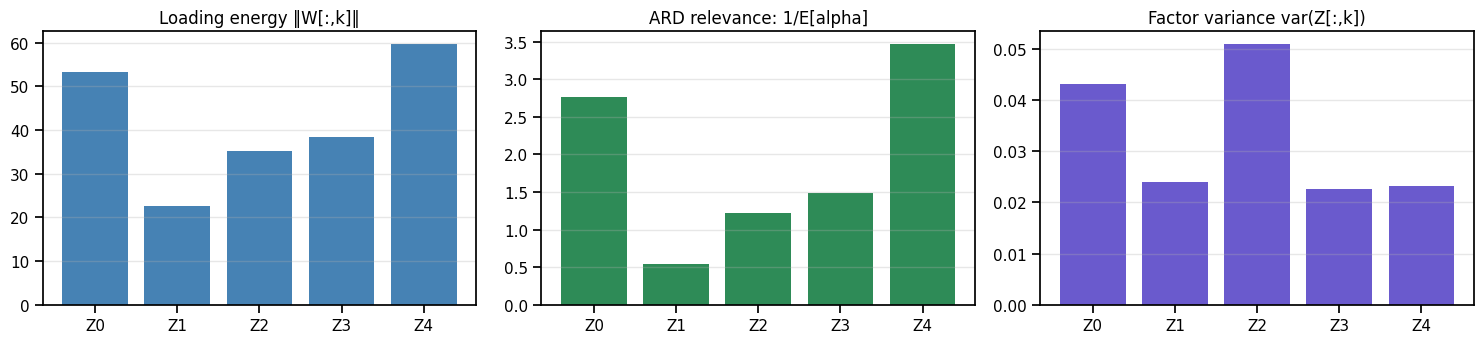

In [36]:
# 9b — factor relevance: energy ‖W‖, ARD 1/E[alpha], var(Z)
W0 = get_W(mc, 0)
energy = np.linalg.norm(W0, axis=0)
relevance = 1.0 / factor_alpha(mc, 0)
zvar = mc.get_latent_factors().var(0)
tab = pd.DataFrame({'‖W[:,k]‖ (energia)': energy.round(3),
                    '1/E[alpha] (ARD)':   relevance.round(3),
                    'var(Z[:,k])':        zvar.round(3)}, index=factors)
print(tab.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].bar(factors, energy, color='steelblue');  axes[0].set_title('Loading energy ‖W[:,k]‖')
axes[1].bar(factors, relevance, color='seagreen'); axes[1].set_title('ARD relevance: 1/E[alpha]')
axes[2].bar(factors, zvar, color='slateblue');     axes[2].set_title('Factor variance var(Z[:,k])')
for ax in axes:
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### 9d — R² matrix: factors vs views / cohorts
Rank-1 R² of each factor per view and per cohort — the division of labour across
factors.

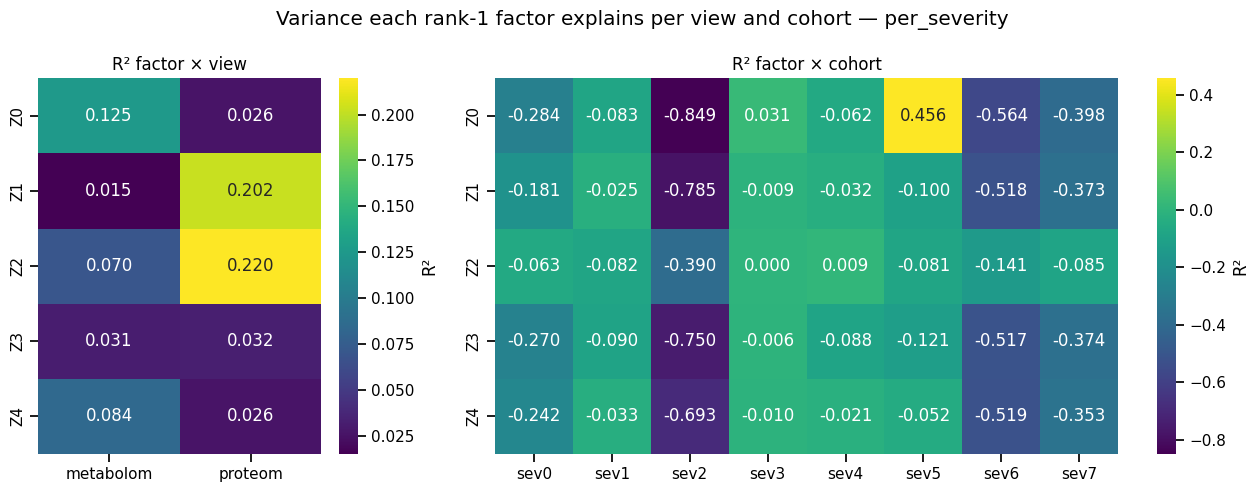

In [37]:
# 9d — R² matrix: how much each FACTOR explains of each VIEW and each COHORT
# Rekonstrukcja rank-1 z pojedynczego faktora: Ŷ_k = Z[:,k] ⊗ W[:,k]; R² = 1 - SS_res/SS_tot.
mode = 'per_severity'
d = get_data(mode); views = d.views
mc = get_fit(mode, 'cohort', K=HEADLINE_K)
Z = mc.get_latent_factors()
names, codes = np.unique(d.cohorts, return_inverse=True)
fl = [f'Z{k}' for k in range(HEADLINE_K)]
view_names = ['metabolom', 'proteom']


def var_expl(Y, Yh):
    return 1.0 - ((Y - Yh) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()


# faktor × widok
R2_fv = np.zeros((HEADLINE_K, views.num_simple))
for k in range(HEADLINE_K):
    for vi in range(views.num_simple):
        Yh_k = np.outer(Z[:, k], get_W(mc, vi)[:, k])
        R2_fv[k, vi] = var_expl(np.asarray(views.simple[vi].data), Yh_k)

# factor × cohort (concatenated views; R² on each cohort's samples)
Ycat = np.hstack([np.asarray(views.simple[vi].data) for vi in range(views.num_simple)])
R2_fc = np.zeros((HEADLINE_K, len(names)))
for k in range(HEADLINE_K):
    Yh_k = np.hstack([np.outer(Z[:, k], get_W(mc, vi)[:, k]) for vi in range(views.num_simple)])
    for ci in range(len(names)):
        m = codes == ci
        R2_fc[k, ci] = var_expl(Ycat[m], Yh_k[m])

fig, axes = plt.subplots(1, 2, figsize=(13, 0.5 * HEADLINE_K + 2.5),
                         gridspec_kw={'width_ratios': [1, 2.2]})
sns.heatmap(R2_fv, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=view_names, yticklabels=fl, ax=axes[0], cbar_kws={'label': 'R²'})
axes[0].set_title('R² factor × view')
sns.heatmap(R2_fc, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=names, yticklabels=fl, ax=axes[1], cbar_kws={'label': 'R²'})
axes[1].set_title('R² factor × cohort')
plt.suptitle('Variance each rank-1 factor explains per view and cohort — per_severity')
plt.tight_layout(); plt.show()

`E[W]` shows a block feature→factor structure; ARD-pruned factors have low
energy.